### Geodesic Tracking
This notebook performs the geodesic tracking experiment.

In [1]:
import pymanopt
import autograd.numpy as np
from flag import *
from utils import *
import os
NOISE_LEVEL = 1e-4
TRACKING_LENGTH = 200
T_SWITCH = TRACKING_LENGTH // 2
SUBSPACE_CHANGE_RATE = 5e-5
SAVE_FOLDER = "plots_geodesic_tracking"
os.makedirs(SAVE_FOLDER, exist_ok=True)
np.random.seed(42)

def generate_geodesic(ambient_dim):
    subspace_dim = 5
    flag = Flag(ambient_dim, tuple(range(1, subspace_dim + 1)))
    top = np.diag([1, 1, 1, 1, 1])
    bottom = np.zeros((ambient_dim - subspace_dim, subspace_dim))
    current_point = np.vstack((top, bottom))
    true_subspaces = []
    for t in range(TRACKING_LENGTH):
        random_direction = flag.random_tangent_vector(current_point)
        next_point = flag.exponential_map(current_point, SUBSPACE_CHANGE_RATE * random_direction)
        if t == T_SWITCH:
            subspace_dim += 1
            new_basis = np.zeros((ambient_dim, 1))
            new_basis[subspace_dim, :] = 3
            flag = Flag(ambient_dim, tuple(range(1, subspace_dim + 1)))
            next_point = np.hstack((next_point, new_basis))
        true_subspaces.append(next_point)
        current_point = next_point

    return true_subspaces

def recon_error(point, sample, level):
    projector = point[:, :level] @ point[:, :level].T
    return np.linalg.norm(sample - projector @ sample, ord=2) / np.linalg.norm(sample, ord=2)

def plot_subspace_distances(distance, metric, window, flag_name, save_folder):
    fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(12, 8))
    axes[0].plot(distance, color=soft_colors['soft_blue'],
                 label='chordal distance')
    axes[0].legend()
    axes[1].plot(metric, color=soft_colors['soft_orange'],
                 label='chordal metric')
    axes[1].legend()

    for ax in axes:
        ax.grid(True)

    fig.suptitle(f'Subspace distances (data window: {window}), {flag_name}')
    save_path = os.path.join(save_folder, f"subspace_distances_window_{window}_{flag_name}.png")
    plt.savefig(save_path, dpi=300)

def plot_multi_level_error(multi_level_errors, window, flag_name, t_switch, save_folder):
    nrows = np.shape(multi_level_errors)[0]
    fig, axes = plt.subplots(
        nrows,
        ncols=1,
        figsize=(8, 1.5 * nrows),
        sharex=True
    )
    if nrows == 1:
        axes = [axes]
    for j in range(nrows):
        axes[j].set_ylim(0, 1.0)
        axes[j].plot(multi_level_errors[j, :], label=f'projection error of U_{j + 1}')
        axes[j].legend()
        axes[j].grid()
        axes[j].axvline(t_switch, color='red', linestyle='--', linewidth=1)

    fig.suptitle(f"multi-level error (data window: {window}), {flag_name}")
    save_path = os.path.join(save_folder, f"multi_level_error_window_{window}_{flag_name}.png")
    plt.savefig(save_path, dpi=300)

In [2]:
def flag_online_update(flag, data_window, U_current, num_steps=5):
    signature = flag._signature
    # Define cost function for *current* window X
    @pymanopt.function.autograd(flag)
    def cost(point):
        ambient_dim = np.shape(point)[0]
        flag_trick = np.zeros((ambient_dim, ambient_dim))
        for q_k in signature:
            flag_trick += 1 / len(signature) * point[:, :q_k] @ point[:, :q_k].T
        return np.sum(np.linalg.norm(data_window - flag_trick @ data_window, ord='fro'))

    problem = pymanopt.Problem(flag, cost)
    optimizer_fl = pymanopt.optimizers.SteepestDescent(
        verbosity=0, max_iterations=num_steps
    )
    result_fl = optimizer_fl.run(problem, initial_point=U_current)
    U_next = result_fl.point

    return U_next

def online_subspace_tracking(flag, initial_point, data_set, true_subspaces, window):
    flag_name = flag.name
    signature = flag._signature
    U_0 = initial_point
    num_levels = signature[-1]
    num_iter = 2
    U = [U_0]
    num_tracking = np.shape(data_set)[1] - window + 1
    errors = {
        "chord-metric": [],
        "chord-dist": [],
        "multi-levels": np.zeros((num_levels, num_tracking)),
        "principal-angles": np.zeros((num_levels, num_tracking))
    }

    for t in range(num_tracking):
        sample = data_set[:, t: t + window]
        U_current = U[t]
        U.append(flag_online_update(flag, sample, U[t], num_steps=num_iter))

        for level in range(num_levels):
            errors["multi-levels"][level, t] = recon_error(U_current, sample[:, -1], level + 1)
        principal_angle = compute_principal_angles(true_subspaces[t + window - 1], U[t+1])
        num_angles = len(principal_angle)
        errors["principal-angles"][:num_angles, t] = principal_angle
        errors["principal-angles"][num_angles:, t] = 90
        errors["chord-metric"].append(chordal_metric(U[t], true_subspaces[t + window - 1]))
        errors["chord-dist"].append(chordal_distance(U[t], true_subspaces[t + window - 1]))

    U = U[1:]

    return U, errors

In [3]:
def generate_data_set(true_subspaces):
    data_set = []
    for t, true_subspace in enumerate(true_subspaces):
        coeffs = np.random.randn(true_subspace.shape[1])
        projection = projector(true_subspace)
        noise = NOISE_LEVEL * (np.eye(np.shape(projection)[0]) - projection) @ np.random.randn(true_subspace.shape[0])
        sample = true_subspace @ coeffs + noise
        data_set.append(sample.reshape(-1, 1))

    return np.hstack(data_set)

def run_online_tracking_experiments(flag, windows, true_subspaces, num_experiments, save_folder):
    flag_name = flag.name
    flag_name_simple = f"flag_{flag._signature[0]}to{flag._signature[-1]}"
    data_set = generate_data_set(true_subspaces)
    for window in windows:
        num_tracking = len(true_subspaces) - window + 1
        dim = flag._signature[-1]
        multi_level_errors = np.zeros((dim, num_tracking, num_experiments))
        chordal_distances = np.zeros((num_tracking, num_experiments))
        chordal_metrics = np.zeros((num_tracking, num_experiments))
        initial_point = flag.random_point()
        for experiment in range(num_experiments):
            U, errors = online_subspace_tracking(flag, initial_point, data_set, true_subspaces, window)
            multi_level_errors[:, :, experiment] = errors["multi-levels"]
            chordal_distances[:, experiment] = np.array(errors["chord-dist"])
            chordal_metrics[:, experiment] = np.array(errors["chord-metric"])
        avg_multi_level_errors = np.mean(multi_level_errors, axis=2)
        avg_chordal_distances = np.mean(chordal_distances, axis=1)
        avg_chordal_metrics = np.mean(chordal_metrics, axis=1)
        plot_multi_level_error(avg_multi_level_errors, window, flag_name, T_SWITCH, save_folder)
        plot_subspace_distances(avg_chordal_distances, avg_chordal_metrics, window, flag_name, save_folder)
        prefix = f"{window}_{flag_name_simple}"
        save_data(avg_multi_level_errors.T, filename=f"multi_level_errors_{prefix}", save_folder=SAVE_FOLDER)
        save_data(avg_chordal_distances, filename=f"chordal_distances_{prefix}", save_folder=SAVE_FOLDER)
        save_data(avg_chordal_metrics, filename=f"chordal_metrics_{prefix}", save_folder=SAVE_FOLDER)



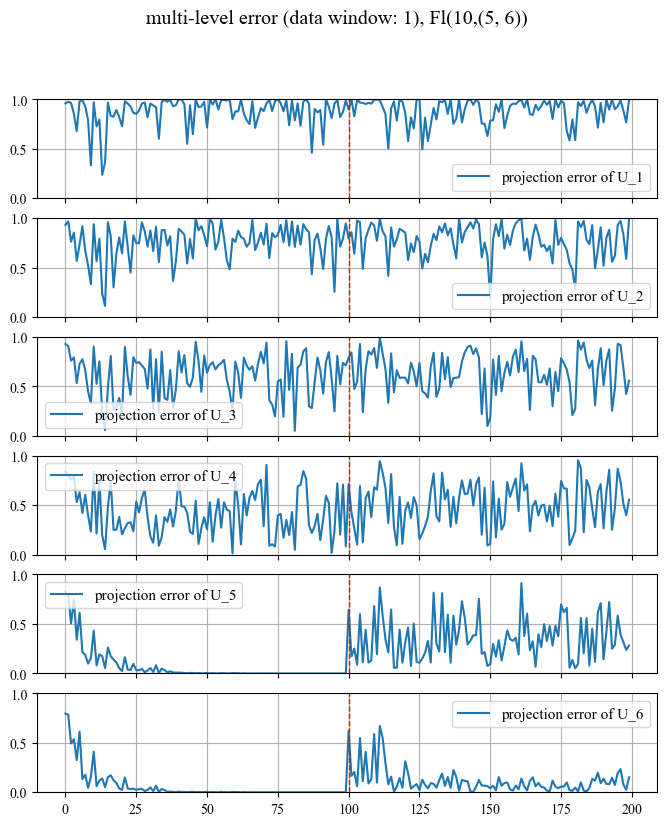

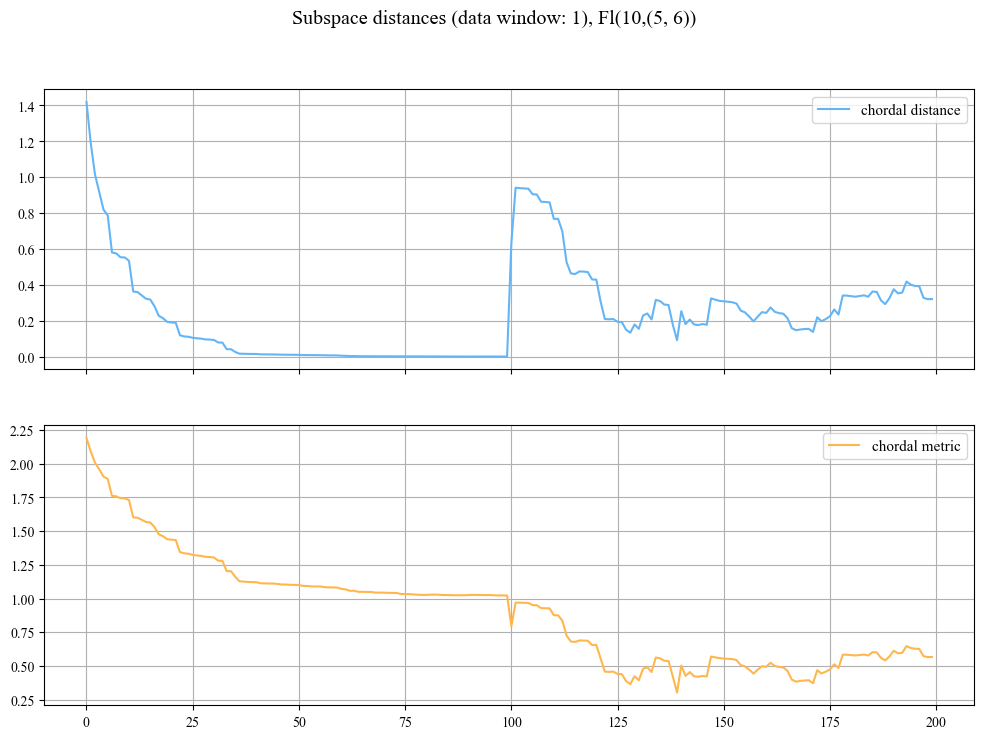

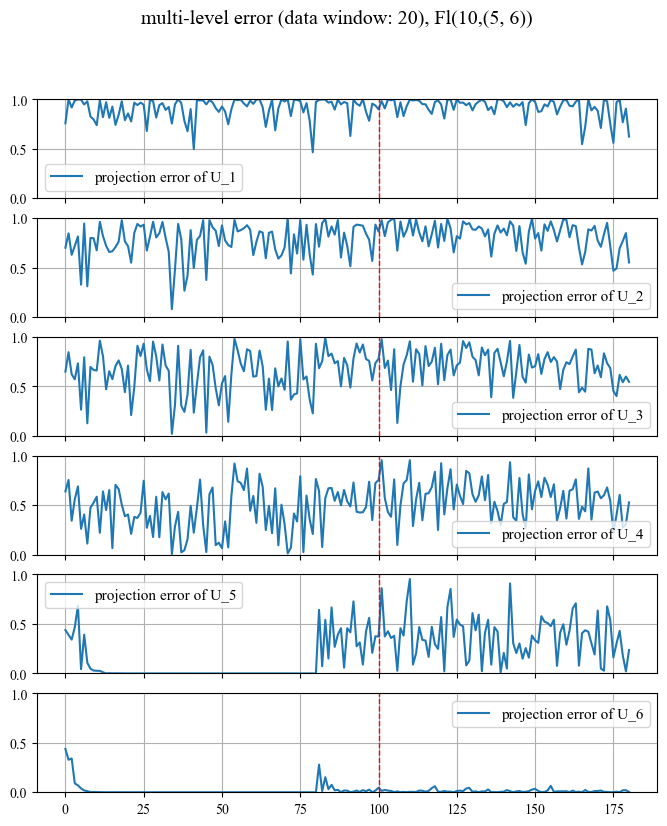

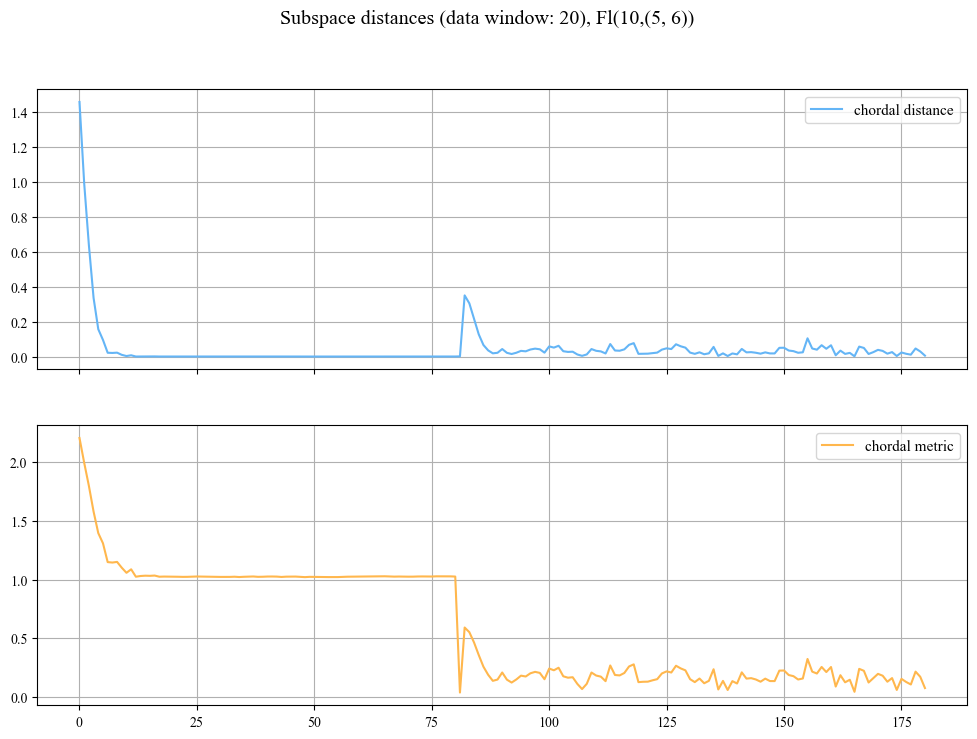

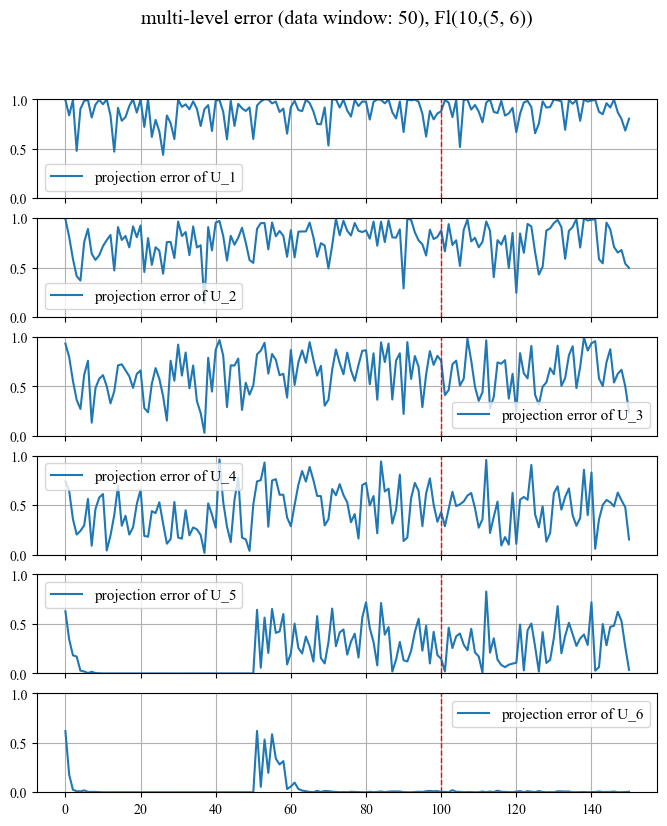

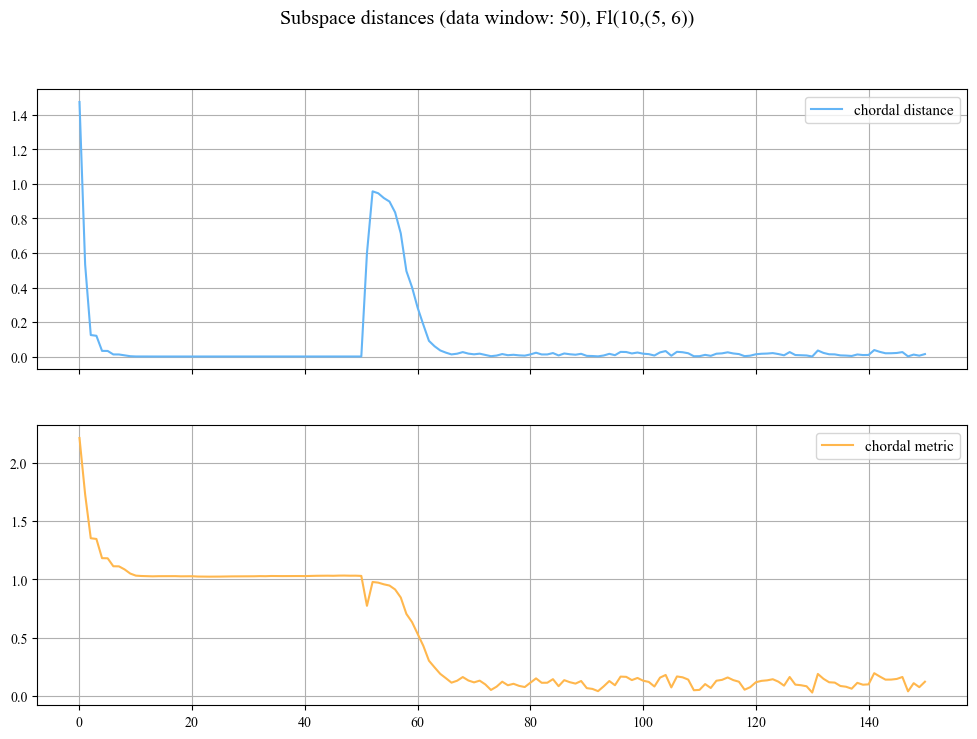

In [4]:
ambient_dim = 10
windows = [1, 20, 50]
num_experiments = 100
true_subspaces = generate_geodesic(ambient_dim)
signature = (5, 6)
# signature = (6,)
flag = Flag(ambient_dim, signature)
run_online_tracking_experiments(flag, windows, true_subspaces, num_experiments, SAVE_FOLDER)